# CLIP Fine-Tuning V2 - Egypt Landmarks
**Memory-optimized version with:**
- Mixed precision (FP16) training
- Gradient accumulation
- Proper trainable linear classifier head
- Data augmentation
- Learning rate scheduler with warmup
- Early stopping

In [24]:
!pip install -q torch torchvision transformers open_clip_torch pillow matplotlib pandas tqdm scikit-learn

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T
from PIL import Image
import open_clip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings
import gc
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [26]:
# Setup paths - Kaggle
DATASET_PATH = Path('/kaggle/input/datasets/omarsalah123/updated-landmark-data/images')
SAVE_DIR = Path('/kaggle/working/clip_egypt_models_v2')
SAVE_DIR.mkdir(exist_ok=True, parents=True)

# Memory-optimized config
CONFIG = {
    'min_images': 15,
    'batch_size': 4,            # Reduced for memory
    'accumulation_steps': 4,    # Effective batch = 8 * 4 = 32
    'epochs': 5,
    'lr': 2e-5,
    'warmup_epochs': 2,
    'patience': 8,
    'clip_model': 'ViT-L-14',   # Large model with memory optimizations
    'pretrained': 'openai',
    'num_workers': 0,
    'unfreeze_layers': 6,
    'use_amp': True,            # Mixed precision for memory savings
}

In [27]:
# Load all classes
all_classes = {}
for folder in sorted(DATASET_PATH.iterdir()):
    if folder.is_dir():
        imgs = [f for f in folder.iterdir() if f.suffix.lower() in ['.jpg','.jpeg','.png','.webp']]
        if len(imgs) >= CONFIG['min_images']:
            all_classes[folder.name] = imgs

class_names = sorted(all_classes.keys())
class_to_idx = {n: i for i, n in enumerate(class_names)}
num_classes = len(class_names)

class_counts = {c: len(imgs) for c, imgs in all_classes.items()}
total_images = sum(class_counts.values())
print(f"Classes: {num_classes}, Total images: {total_images}")
print(f"Avg images/class: {total_images/num_classes:.1f}")

Classes: 110, Total images: 4342
Avg images/class: 39.5


In [28]:
# Build dataset
data = [{'path': str(p), 'label': class_to_idx[c], 'class': c} 
        for c, imgs in all_classes.items() for p in imgs]
df = pd.DataFrame(data)

train, test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train, val = train_test_split(train, test_size=0.15, stratify=train['label'], random_state=42)
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 2952, Val: 521, Test: 869


In [29]:
# Load CLIP model
print(f"Loading {CONFIG['clip_model']}...")
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    CONFIG['clip_model'], pretrained=CONFIG['pretrained'])
clip_model = clip_model.to(device)
tokenizer = open_clip.get_tokenizer(CONFIG['clip_model'])

embed_dim = clip_model.visual.output_dim
print(f"Embedding dim: {embed_dim}")

# Clear cache
if device.type == 'cuda':
    torch.cuda.empty_cache()
    gc.collect()

Loading ViT-L-14...
Embedding dim: 768


In [30]:
# Data augmentation
train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), 
                std=(0.26862954, 0.26130258, 0.27577711)),
])

class CLIPDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self): 
        return len(self.df)
    
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(r['path']).convert('RGB')
        img = self.transform(img)
        return img, r['label']

train_dl = DataLoader(CLIPDataset(train, train_transform), CONFIG['batch_size'], 
                      shuffle=True, num_workers=CONFIG['num_workers'], pin_memory=True)
val_dl = DataLoader(CLIPDataset(val, preprocess), CONFIG['batch_size'], 
                    num_workers=CONFIG['num_workers'], pin_memory=True)
test_dl = DataLoader(CLIPDataset(test, preprocess), CONFIG['batch_size'], 
                     num_workers=CONFIG['num_workers'], pin_memory=True)

In [31]:
# Memory-efficient classifier
class CLIPClassifierV2(nn.Module):
    def __init__(self, clip_model, num_classes, embed_dim, unfreeze_layers=4):
        super().__init__()
        self.visual = clip_model.visual
        
        # Freeze all layers first
        for param in self.visual.parameters():
            param.requires_grad = False
        
        # Unfreeze last N transformer blocks
        if hasattr(self.visual, 'transformer'):
            num_blocks = len(self.visual.transformer.resblocks)
            for i in range(num_blocks - unfreeze_layers, num_blocks):
                for param in self.visual.transformer.resblocks[i].parameters():
                    param.requires_grad = True
        
        # Always unfreeze final layers
        for name, param in self.visual.named_parameters():
            if any(x in name for x in ['ln_post', 'proj']):
                param.requires_grad = True
        
        # Trainable classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(0.2),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim // 2, num_classes)
        )
        
    def forward(self, images):
        features = self.visual(images)
        features = features / features.norm(dim=-1, keepdim=True)
        return self.classifier(features)

model = CLIPClassifierV2(clip_model, num_classes, embed_dim, 
                         unfreeze_layers=CONFIG['unfreeze_layers']).to(device)

# Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# Clear cache after model creation
if device.type == 'cuda':
    torch.cuda.empty_cache()

Trainable: 227,792,110 / 304,305,390 (74.9%)


In [32]:
# Class weights for imbalanced data
train_labels = train['label'].values
label_counts = Counter(train_labels)
class_weights = torch.tensor(
    [1.0 / label_counts[i] for i in range(num_classes)], 
    dtype=torch.float32
).to(device)
class_weights = class_weights / class_weights.sum() * num_classes

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

In [33]:
@torch.no_grad()
def evaluate(model, dl):
    model.eval()
    correct = total = 0
    all_preds, all_labels = [], []
    
    for imgs, labels in dl:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(enabled=CONFIG['use_amp']):
            logits = model(imgs)
        _, pred = logits.max(1)
        correct += pred.eq(labels).sum().item()
        total += labels.size(0)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return 100 * correct / total, all_preds, all_labels

# Zero-shot baseline (will be ~random since classifier is untrained)
zero_shot_acc, _, _ = evaluate(model, test_dl)
print(f"Baseline accuracy (untrained classifier): {zero_shot_acc:.2f}%")

Baseline accuracy (untrained classifier): 0.81%


In [34]:
# Optimizer and scheduler
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                        lr=CONFIG['lr'], weight_decay=0.01)

# Mixed precision scaler
scaler = GradScaler(enabled=CONFIG['use_amp'])

# Warmup + Cosine schedule
def get_lr(epoch):
    if epoch < CONFIG['warmup_epochs']:
        return (epoch + 1) / CONFIG['warmup_epochs']
    else:
        progress = (epoch - CONFIG['warmup_epochs']) / (CONFIG['epochs'] - CONFIG['warmup_epochs'])
        return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, get_lr)

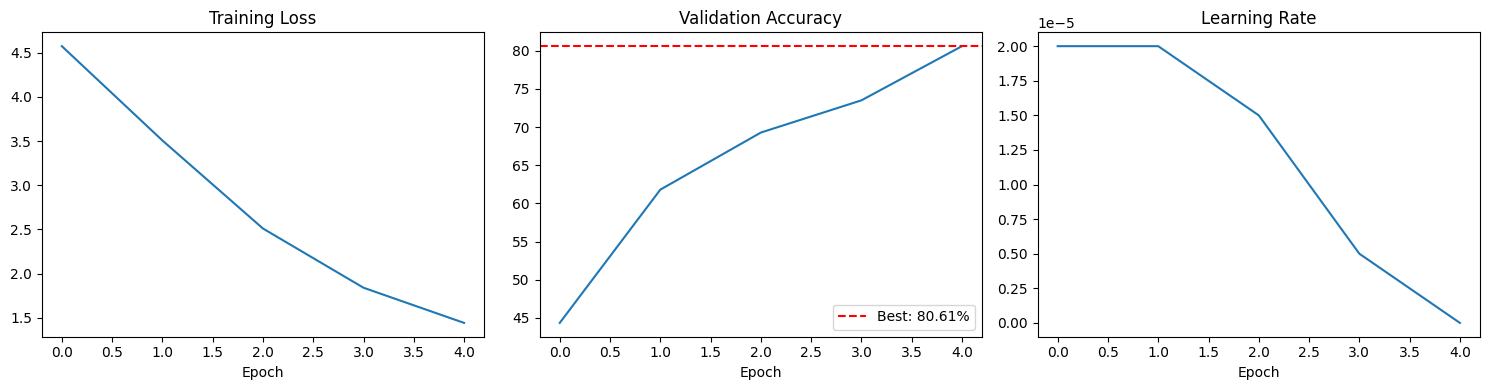

In [36]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_acc'])
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].axhline(y=best_acc, color='r', linestyle='--', label=f'Best: {best_acc:.2f}%')
axes[1].legend()

axes[2].plot(history['lr'])
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_history.png', dpi=150)
plt.show()

In [37]:
# Load best model and evaluate on test set
checkpoint = torch.load(SAVE_DIR / 'clip_v2_best.pth')
model.load_state_dict(checkpoint['model'])

test_acc, preds, labels = evaluate(model, test_dl)

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Baseline (untrained):     {zero_shot_acc:.2f}%")
print(f"Fine-tuned CLIP V2:       {test_acc:.2f}%")
print(f"Classes:                  {num_classes}")
print(f"Test samples:             {len(test)}")
print(f"Model:                    {CONFIG['clip_model']}")


FINAL RESULTS
Baseline (untrained):     0.81%
Fine-tuned CLIP V2:       79.40%
Classes:                  110
Test samples:             869
Model:                    ViT-L-14


In [38]:
# Top-5 accuracy
@torch.no_grad()
def top_k_accuracy(model, dl, k=5):
    model.eval()
    correct = total = 0
    for imgs, labels in dl:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(enabled=CONFIG['use_amp']):
            logits = model(imgs)
        _, topk = logits.topk(k, dim=1)
        correct += topk.eq(labels.view(-1, 1)).sum().item()
        total += labels.size(0)
    return 100 * correct / total

top5_acc = top_k_accuracy(model, test_dl, k=5)
print(f"\nTop-5 Accuracy: {top5_acc:.2f}%")


Top-5 Accuracy: 92.17%


In [39]:
# Inference function
def predict(image_path, top_k=5):
    model.eval()
    img = preprocess(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad(), autocast(enabled=CONFIG['use_amp']):
        logits = model(img)
        probs = logits.softmax(dim=-1)[0]
        topk = probs.topk(top_k)
    
    results = []
    for prob, idx in zip(topk.values, topk.indices):
        results.append((class_names[idx], prob.item() * 100))
    return results

# Test on a sample
sample_path = test.iloc[0]['path']
true_label = test.iloc[0]['class']
predictions = predict(sample_path)

print(f"\nSample prediction:")
print(f"True label: {true_label}")
print("Top-5 predictions:")
for name, prob in predictions:
    marker = "✓" if name == true_label else " "
    print(f"  {marker} {name}: {prob:.1f}%")


Sample prediction:
True label: Temple_of_Kom_Ombo
Top-5 predictions:
  ✓ Temple_of_Kom_Ombo: 67.0%
    Temple_of_Khonsu_in_Karnak: 1.7%
    Great_Hypostyle_Hall_of_Karnak: 1.5%
    Esna_Temple: 1.1%
    Temple_of_Hibis: 0.9%


In [40]:
# Per-class accuracy analysis
from collections import defaultdict

class_correct = defaultdict(int)
class_total = defaultdict(int)

for pred, label in zip(preds, labels):
    class_total[label] += 1
    if pred == label:
        class_correct[label] += 1

class_acc = {class_names[i]: 100 * class_correct[i] / class_total[i] 
             for i in range(num_classes) if class_total[i] > 0}

sorted_acc = sorted(class_acc.items(), key=lambda x: x[1])
print("\nWorst performing classes:")
for name, acc in sorted_acc[:10]:
    print(f"  {name}: {acc:.0f}%")

print("\nBest performing classes:")
for name, acc in sorted_acc[-10:]:
    print(f"  {name}: {acc:.0f}%")


Worst performing classes:
  Dendera_Temple_complex: 25%
  Qaed_Ibrahim_Mosque: 25%
  Theban_Necropolis: 25%
  Al-Ashraf_Mosque: 33%
  Corniche_(Alexandria): 33%
  Edfu_Temple: 33%
  Karnak_precinct_of_Amun-Ra: 33%
  Temple_of_Seti_I_in_Abydos: 33%
  Temple_of_Hibis: 38%
  Wadi_el_Gemal_National_Park: 40%

Best performing classes:
  Pyramid_of_Menkaure: 100%
  Pyramid_of_Unas: 100%
  Ras_Muhammad: 100%
  Sphinx_of_Memphis: 100%
  Suez_Canal_Bridge: 100%
  Temple_of_Isis_in_Philae: 100%
  Tomb_of_Unknown_Soldier_in_Cairo: 100%
  Unfinished_obelisk_in_Aswan: 100%
  Wadi_el-Raiyan: 100%
  White_Monastery: 100%


In [41]:
print("\nModel saved to:", SAVE_DIR / 'clip_v2_best.pth')


Model saved to: /kaggle/working/clip_egypt_models_v2/clip_v2_best.pth


In [42]:
!pip install fastapi uvicorn pyngrok transformers accelerate -q

In [43]:
from fastapi import FastAPI, Request, HTTPException
import socket, threading, time
from pyngrok import ngrok, conf
import uvicorn

from fastapi import FastAPI, File, UploadFile, Request, HTTPException, Header
import torch
from PIL import Image
import io
import socket
import threading
import time
import uvicorn
from pyngrok import ngrok, conf

app = FastAPI()


In [44]:
NGROK_TOKEN = "32MSvnxHYuCSMfAqXpo8t9mclY3_3cdfVkrD4ECodqaxDSzA1"
API_KEY = "secret123"

app = FastAPI()

In [45]:
@app.post("/predict")
async def predict(req: Request, file: UploadFile = File(...)):

    # auth (same style as your /generate)
    if req.headers.get("authorization") != f"Bearer {API_KEY}":
        raise HTTPException(status_code=401, detail="Unauthorized")

    image_bytes = await file.read()
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

    img = preprocess(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(img)
        probs = torch.softmax(logits, dim=1)[0]

    top_idx = torch.argmax(probs).item()
    label = class_names[top_idx]
    confidence = float(probs[top_idx]) * 100

    return {
        "label": label,
        "confidence": confidence
    }

In [46]:
def free_port():
    s = socket.socket()
    s.bind(('', 0))
    port = s.getsockname()[1]
    s.close()
    return port

In [47]:
port = free_port()

conf.get_default().auth_token = NGROK_TOKEN
public_url = ngrok.connect(port).public_url

print("Your public URL:", public_url)
print("Predict endpoint:", public_url + "/predict")

Your public URL: https://12e1-8-229-115-241.ngrok-free.app                                          
Predict endpoint: https://12e1-8-229-115-241.ngrok-free.app/predict


In [48]:
def run():
    uvicorn.run(app, host="0.0.0.0", port=port)

threading.Thread(target=run, daemon=True).start()
time.sleep(2)

INFO:     Started server process [58]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:33129 (Press CTRL+C to quit)


In [49]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 70.6 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [50]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

In [51]:
img_path = sample_path

image = Image.open(img_path).convert("RGB")

In [52]:
input_tensor = preprocess(image).unsqueeze(0).to(device)

rgb_img = np.array(
    image.resize((224, 224))
).astype(np.float32) / 255.0

In [53]:
def reshape_transform(tensor):

    # remove CLS token
    tensor = tensor[:, 1:, :]

    # ViT-L/14 with 224x224 image
    h = w = int(np.sqrt(tensor.shape[1]))

    result = tensor.reshape(
        tensor.size(0),
        h,
        w,
        tensor.size(2)
    )

    result = result.permute(0, 3, 1, 2)

    return result

In [54]:
target_layers = [
    model.visual.transformer.resblocks[-1].ln_1
]

In [55]:
cam = GradCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

In [56]:
model.eval()

with torch.no_grad():
    output = model(input_tensor)

pred_class = output.argmax(dim=1).item()

print("Predicted class:")
print(class_names[pred_class])

Predicted class:
Temple_of_Kom_Ombo


In [57]:
targets = [
    ClassifierOutputTarget(pred_class)
]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)[0]

In [58]:
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

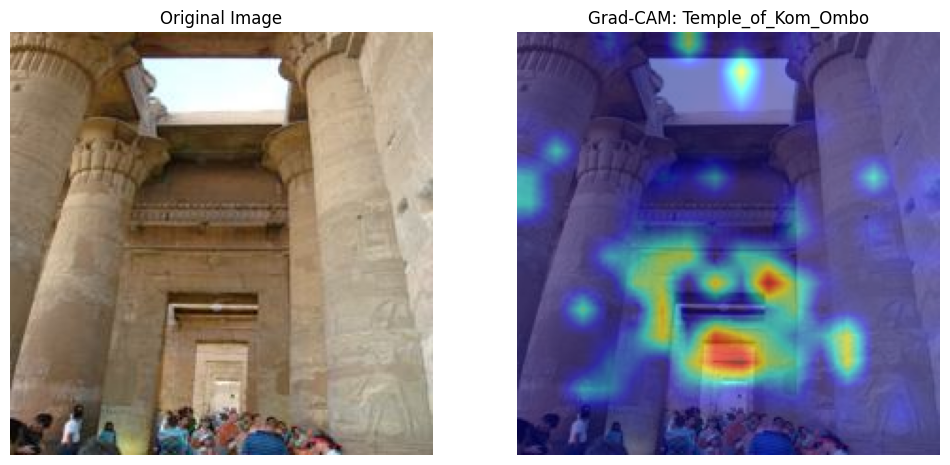

In [60]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(f"Grad-CAM: {class_names[pred_class]}")
plt.axis("off")

plt.show()

In [61]:
def run_gradcam(img_path):
    image = Image.open(img_path).convert("RGB")

    input_tensor = preprocess(image).unsqueeze(0).to(device)

    rgb_img = np.array(image.resize((224, 224))).astype(np.float32) / 255.0

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    pred_class = output.argmax(dim=1).item()

    print("Predicted:", class_names[pred_class])

    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM: {class_names[pred_class]}")
    plt.axis("off")

    plt.show()

Predicted: Mosque-Madrassa_of_Sultan_Hassan


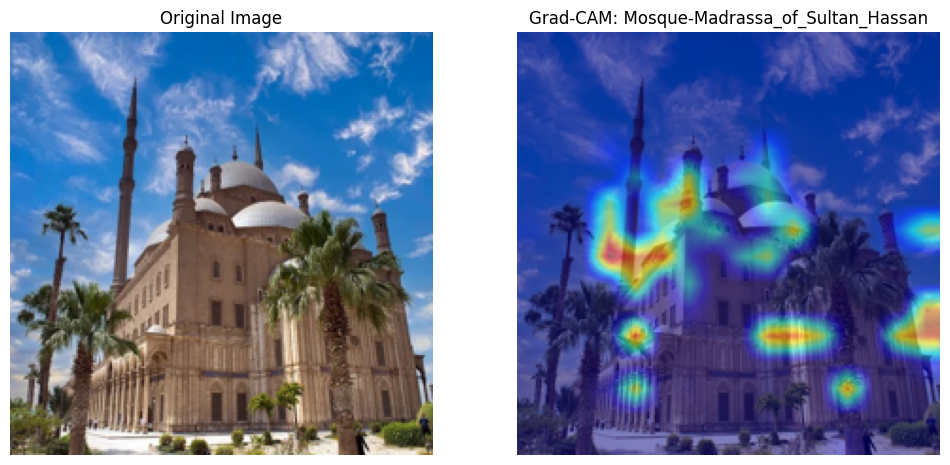

Predicted: 6_October_Bridge


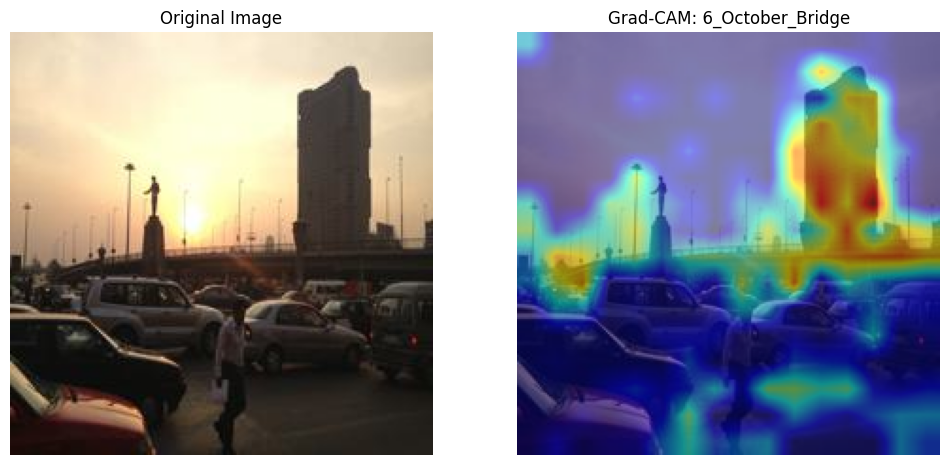

Predicted: Agiba_beach


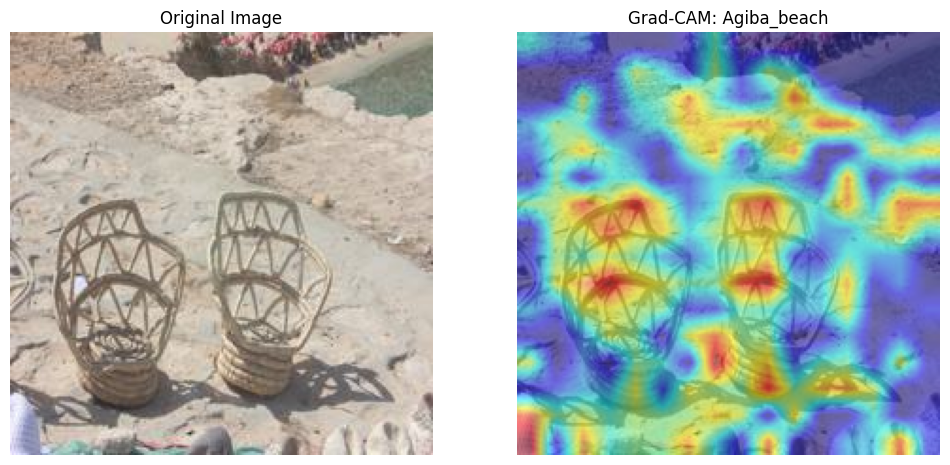

Predicted: El_Alamein_Military_Museum


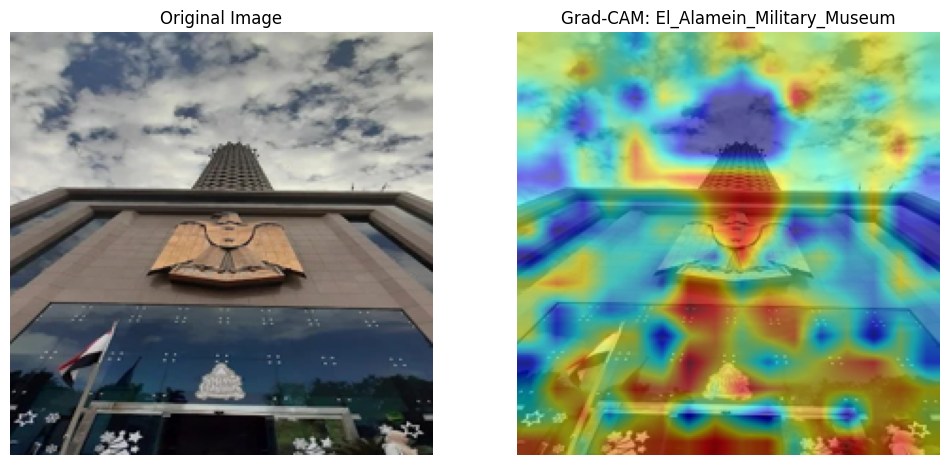

In [68]:
run_gradcam("/kaggle/input/datasets/omarsalah123/updated-landmark-data/images/Citadel of Salah Eldin/1.jpeg")
run_gradcam("/kaggle/input/datasets/omarsalah123/updated-landmark-data/images/6_October_Bridge/0.jpg")
run_gradcam("/kaggle/input/datasets/omarsalah123/updated-landmark-data/images/Agiba_beach/0.jpg")
run_gradcam("/kaggle/input/datasets/omarsalah123/updated-landmark-data/images/Cairo Tower/1.jpeg")